In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**During initial ETL process:** Removed an unspecified column, converted ship date and order date to proper format, and saved as csv file. 

In [50]:
# Load the dataset
df = pd.read_csv("superstore.csv")

In [51]:
# Display the first few rows of the dataset
df.head()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,Order.Date,Order.ID,Order.Priority,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,00:00.0,CA-2011-130813,High,...,19,Consumer,00:00.0,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,00:00.0,CA-2011-148614,Medium,...,19,Consumer,00:00.0,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,00:00.0,CA-2011-118962,Medium,...,21,Consumer,00:00.0,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,00:00.0,CA-2011-118962,Medium,...,111,Consumer,00:00.0,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,00:00.0,CA-2011-146969,High,...,6,Consumer,00:00.0,Standard Class,1.32,California,Paper,2011,North America,40


In [52]:
# Display the column names of the dataset
df.columns

Index(['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name',
       'Discount', 'Market', 'Order.Date', 'Order.ID', 'Order.Priority',
       'Product.ID', 'Product.Name', 'Profit', 'Quantity', 'Region', 'Row.ID',
       'Sales', 'Segment', 'Ship.Date', 'Ship.Mode', 'Shipping.Cost', 'State',
       'Sub.Category', 'Year', 'Market2', 'weeknum'],
      dtype='str')

In [53]:
# Display the summary information of the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  str    
 1   City            51290 non-null  str    
 2   Country         51290 non-null  str    
 3   Customer.ID     51290 non-null  str    
 4   Customer.Name   51290 non-null  str    
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  str    
 7   Order.Date      51290 non-null  str    
 8   Order.ID        51290 non-null  str    
 9   Order.Priority  51290 non-null  str    
 10  Product.ID      51290 non-null  str    
 11  Product.Name    51290 non-null  str    
 12  Profit          51290 non-null  float64
 13  Quantity        51290 non-null  int64  
 14  Region          51290 non-null  str    
 15  Row.ID          51290 non-null  int64  
 16  Sales           51290 non-null  int64  
 17  Segment         51290 non-null  str    
 1

In [54]:
# Display the summary statistics of the dataset
df.describe()

,Discount,Profit,Quantity,Row.ID,Sales,Shipping.Cost,Year,weeknum
count,51290.000000,51290.000000,51290.000000,51290.00000,51290.000000,51290.000000,51290.000000,51290.000000
mean,0.142908,28.610982,3.476545,25645.50000,246.498440,26.375818,2012.777208,31.287112
std,0.212280,174.340972,2.278766,14806.29199,487.567175,57.296810,1.098931,14.429795
min,0.000000,-6599.978000,1.000000,1.00000,0.000000,0.002000,2011.000000,1.000000
25%,0.000000,0.000000,2.000000,12823.25000,31.000000,2.610000,2012.000000,20.000000
50%,0.000000,9.240000,3.000000,25645.50000,85.000000,7.790000,2013.000000,33.000000
75%,0.200000,36.810000,5.000000,38467.75000,251.000000,24.450000,2014.000000,44.000000
max,0.850000,8399.976000,14.000000,51290.00000,22638.000000,933.570000,2014.000000,53.000000


In [55]:
# Convert the "Order.Date" and "Ship.Date" columns to datetime format
df["Order.Date"] = pd.to_datetime(df["Order.Date"])
df["Ship.Date"] = pd.to_datetime(df["Ship.Date"])

In [56]:
# Confirm the changes by displaying the summary information again
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Category        51290 non-null  str           
 1   City            51290 non-null  str           
 2   Country         51290 non-null  str           
 3   Customer.ID     51290 non-null  str           
 4   Customer.Name   51290 non-null  str           
 5   Discount        51290 non-null  float64       
 6   Market          51290 non-null  str           
 7   Order.Date      51290 non-null  datetime64[us]
 8   Order.ID        51290 non-null  str           
 9   Order.Priority  51290 non-null  str           
 10  Product.ID      51290 non-null  str           
 11  Product.Name    51290 non-null  str           
 12  Profit          51290 non-null  float64       
 13  Quantity        51290 non-null  int64         
 14  Region          51290 non-null  str           
 15  Row.ID       

In [57]:
# Calculate overall Key Performance Indicators (KPI's)
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
avg_discount = df["Discount"].mean()

print("Overall Key Performance Indicators (KPI's)")
print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Average Discount: {avg_discount:.2%}")

Overall Key Performance Indicators (KPI's)
Total Sales: $12,642,905.00
Total Profit: $1,467,457.29
Average Discount: 14.29%


In [58]:
# Calculate the average profit margin
df["Profit_Margin"] = df["Profit"] / df["Sales"]
df["Profit_Margin"].mean()

np.float64(-inf)

A sale is $0 so can't divide by zero. 

In [59]:
# Identify orders with zero sales
df[df["Sales"] == 0]

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,Order.Date,Order.ID,Order.Priority,...,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum,Profit_Margin
46158,Office Supplies,Houston,United States,ZC-219104,Zuschuss Carroll,0.8,US,2026-02-25,US-2014-102288,Medium,...,Consumer,2026-02-25,Standard Class,0.01,Texas,Appliances,2014,North America,25,-inf


In [60]:
# Handle zero sales to avoid division by zero when calculating profit margin
df["Profit_Margin"] = np.where(
    df["Sales"] != 0,
    df["Profit"] / df["Sales"],
    0
)

print(f"Profit Margin after handling zero sales: {df['Profit_Margin'].mean() * 100:.2f}%")

Profit Margin after handling zero sales: 4.72%


So on average:
For every $1 of sales, the company keeps about $0.047 (4.7 cents) as profit.
That’s fairly thin.

In [61]:
# Display the summary statistics of the Profit Margin
df["Profit_Margin"].describe()

count    51290.000000
mean         0.047199
std          0.466845
min         -4.727752
25%          0.000000
50%          0.169249
75%          0.333111
max          0.582800
Name: Profit_Margin, dtype: float64

Standard Deviation: 0.4668, large compared to the mean, profit margins very a lot. Some are huge profits, and some are big losses.

Minimum: -472% profit margin, a very big loss- could be from a refund or return? 

50% (Median): Larger than mean, so the large loss transactions are pulling the average down. 

In [62]:
# Analyze profit margin by category
df.groupby("Category")["Profit_Margin"].mean()

Category
Furniture          0.008705
Office Supplies    0.058557
Technology         0.049658
Name: Profit_Margin, dtype: float64

Furniture is high risk — thin margins make losses from discounts or shipping very impactful.

Office Supplies and Technology are better but still only 5–6% margin.

Overall portfolio is low-margin (mean 4.7%), consistent with retail, but highlights that discounts or returns can drastically hurt profitability.

In [63]:
# Create 5 discount bins (0%, 0–10%, 10–20%, etc.)
df["Discount_Bin"] = pd.cut(df["Discount"], bins=[-0.01, 0.1, 0.2, 0.3, 0.5, 1.0],
                             labels=["0-10%", "10-20%", "20-30%", "30-50%", "50%+"])

In [64]:
# Analyze profit margin by category and discount bin
category_discount_margin = df.groupby(["Category", "Discount_Bin"])["Profit_Margin"].mean().reset_index()
category_discount_margin

,Category,Discount_Bin,Profit_Margin
0,Furniture,0-10%,0.238771
1,Furniture,10-20%,0.061810
2,Furniture,20-30%,-0.041800
3,Furniture,30-50%,-0.317520
4,Furniture,50%+,-1.075029
5,Office Supplies,0-10%,0.259648
6,Office Supplies,10-20%,0.186871
7,Office Supplies,20-30%,-0.058425
8,Office Supplies,30-50%,-0.349772
9,Office Supplies,50%+,-1.167357


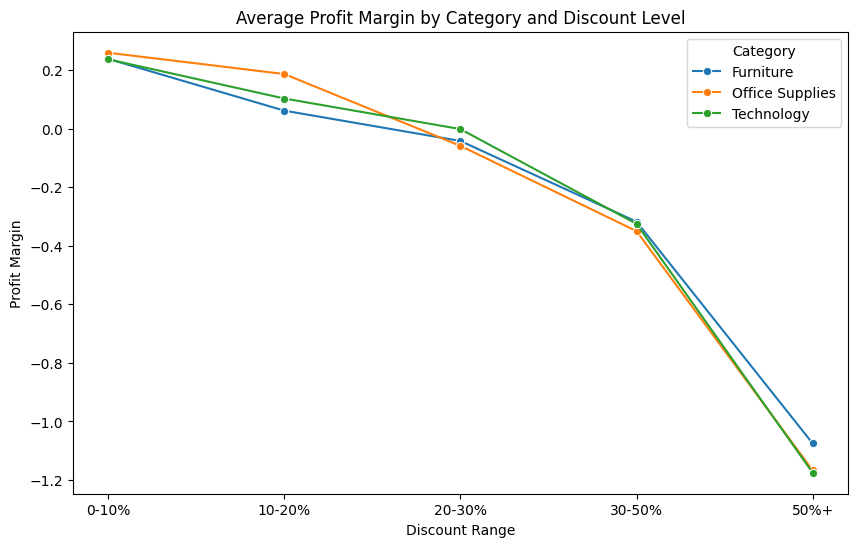

In [65]:
# Visualize the profit margin by category and discount bin
plt.figure(figsize=(10,6))
sns.lineplot(data=category_discount_margin, x="Discount_Bin", y="Profit_Margin", hue="Category", marker="o")
plt.title("Average Profit Margin by Category and Discount Level")
plt.ylabel("Profit Margin")
plt.xlabel("Discount Range")
plt.show()

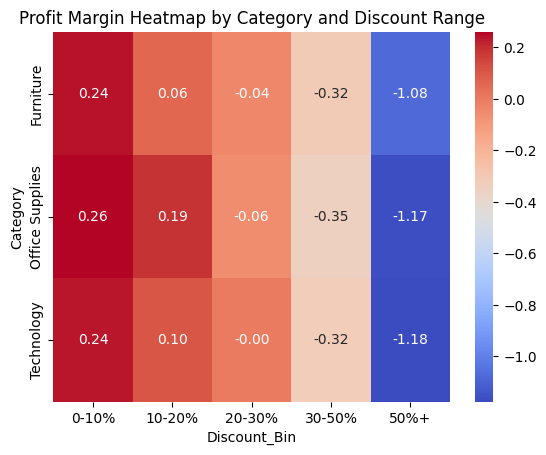

In [66]:
# Create a heatmap to visualize profit margin by category and discount bin
pivot_table = category_discount_margin.pivot(index="Category", columns="Discount_Bin", values="Profit_Margin")
sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Profit Margin Heatmap by Category and Discount Range")
plt.show()

Discount Sensitivity is Extreme:
Margins go from 24–26% to -100%+ with extreme discounts.

Category Differences:
Furniture is very risky, can highlight as strategic recommendation for pricing strategy.
Office Supplies and Technology are slightly more resilient at lower discounts.

Actionable Recommendations:
Limit discounts >30% across categories.
Monitor Furniture and Technology closely for losses during promotions.
Consider alternative promotions (bundling, loyalty programs) instead of steep discounts.

**Regional Analysis**

In [67]:
# Rename the "Region" column to "Sub_Region"
df = df.rename(columns={"Region": "Sub_Region"})

In [68]:
# Standardize the sub-region names for better readability
df["Sub_Region"] = df["Sub_Region"].replace({
    "Central": "Central (USA)",
    "South": "South (USA)",
    "North": "North (USA)",
    "West": "West (USA)",
    "East": "East (USA)"
})
Sub_region_summary = df.groupby("Sub_Region")[["Sales", "Profit"]].sum().sort_values(by="Sales", ascending=False)
Sub_region_summary

,Sales,Profit
Sub_Region,,
Central (USA),2822399,311403.98164
South (USA),1600960,140355.76618
North (USA),1248192,194597.95252
Oceania,1100207,120089.11200
Southeast Asia,884438,17852.32900
North Asia,848349,165578.42100
EMEA,806184,43897.97100
Africa,783776,88871.63100
Central Asia,752839,132480.18700


In [69]:
# Create a mapping of sub-regions to broader regions
region_mapping = {
    # North America
    "West (USA)": "North America",
    "East (USA)": "North America",
    "South (USA)": "North America",
    "Central (USA)": "North America",
    "North (USA)": "North America",
    "Canada": "North America",

    # LATAM
    "Caribbean": "LATAM",

    # EMEA
    "EMEA": "EMEA",
    "Africa": "EMEA",

    # APAC (including Oceania)
    "Southeast Asia": "APAC",
    "North Asia": "APAC",
    "Central Asia": "APAC",
    "Oceania": "APAC"
}

df["Region"] = df["Sub_Region"].map(region_mapping)

In [70]:
# Analyze sales and profit by region
region_summary = df.groupby("Region")[["Sales", "Profit"]].sum().sort_values(by="Sales", ascending=False)
region_summary

,Sales,Profit
Region,,
North America,7142831,864116.31924
APAC,3585833,436000.04900
EMEA,1589960,132769.60200
LATAM,324281,34571.32104


In [71]:
# Display the unique sub-regions and their corresponding regions
df[["Sub_Region", "Region"]].drop_duplicates().sort_values("Region").reset_index(drop=True)

,Sub_Region,Region
0,Central Asia,APAC
1,North Asia,APAC
2,Oceania,APAC
3,Southeast Asia,APAC
4,Africa,EMEA
5,EMEA,EMEA
6,Caribbean,LATAM
7,West (USA),North America
8,East (USA),North America
9,South (USA),North America


In [72]:
# Analyze profit margin by region
region_margin = df.groupby("Region")["Profit_Margin"].mean().sort_values(ascending=False)
region_margin

Region
North America    0.099932
LATAM            0.081182
APAC             0.069545
EMEA            -0.143275
Name: Profit_Margin, dtype: float64

In [73]:
# Analyze profit margin by region and discount bin
region_discount_margin = df.groupby(["Region", "Discount_Bin"])["Profit_Margin"].mean().reset_index()
region_discount_margin

,Region,Discount_Bin,Profit_Margin
0,APAC,0-10%,0.223551
1,APAC,10-20%,0.104834
2,APAC,20-30%,-0.010027
3,APAC,30-50%,-0.357249
4,APAC,50%+,-1.128271
5,EMEA,0-10%,0.246267
6,EMEA,30-50%,-0.215317
7,EMEA,50%+,-1.180399
8,LATAM,0-10%,0.250547
9,LATAM,10-20%,0.072136


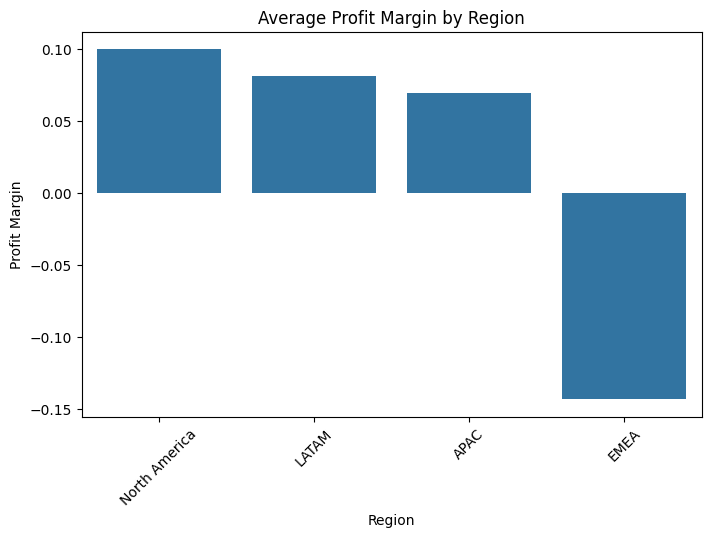

In [74]:
# Visualize the average profit margin by region
plt.figure(figsize=(8,5))
sns.barplot(x=region_margin.index, y=region_margin.values)
plt.title("Average Profit Margin by Region")
plt.ylabel("Profit Margin")
plt.xlabel("Region")
plt.xticks(rotation=45) 
plt.show()

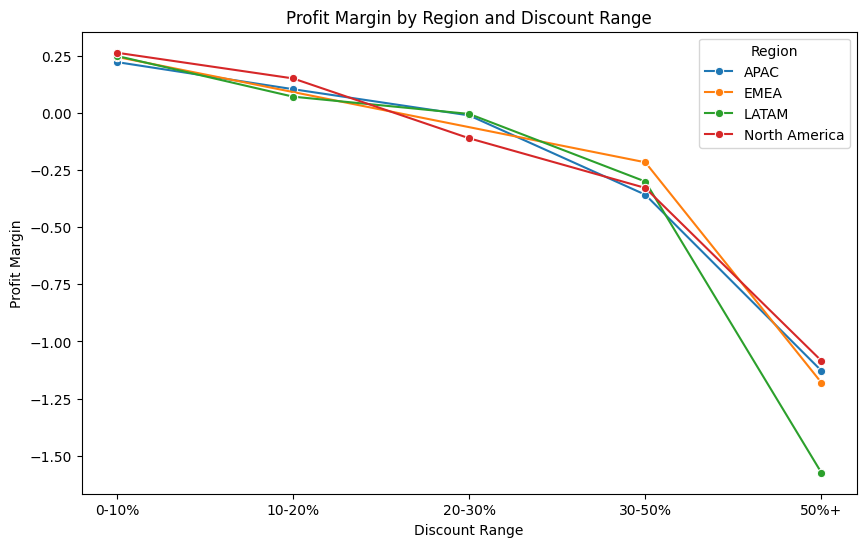

In [75]:
# Visualize the profit margin by region and discount bin
plt.figure(figsize=(10,6))
sns.lineplot(data=region_discount_margin, x="Discount_Bin", y="Profit_Margin", hue="Region", marker="o")
plt.title("Profit Margin by Region and Discount Range")
plt.ylabel("Profit Margin")
plt.xlabel("Discount Range")
plt.show()

In [76]:
# Analyze sales, profit, and profit margin by region
region_summary = df.groupby("Region")[["Sales", "Profit"]].sum()
region_summary["Profit_Margin"] = region_summary["Profit"] / region_summary["Sales"]
region_summary.sort_values(by="Sales", ascending=False)

,Sales,Profit,Profit_Margin
Region,,,
North America,7142831,864116.31924,0.120977
APAC,3585833,436000.04900,0.121590
EMEA,1589960,132769.60200,0.083505
LATAM,324281,34571.32104,0.106609


In [77]:
# Analyze sales and profit by sub-region
subregion_summary = df.groupby("Sub_Region")[["Sales", "Profit"]].sum()
subregion_summary["Profit_Margin"] = subregion_summary["Profit"] / subregion_summary["Sales"]
subregion_summary.sort_values(by="Sales", ascending=False)

,Sales,Profit,Profit_Margin
Sub_Region,,,
Central (USA),2822399,311403.98164,0.110333
South (USA),1600960,140355.76618,0.087670
North (USA),1248192,194597.95252,0.155904
Oceania,1100207,120089.11200,0.109151
Southeast Asia,884438,17852.32900,0.020185
North Asia,848349,165578.42100,0.195177
EMEA,806184,43897.97100,0.054452
Africa,783776,88871.63100,0.113389
Central Asia,752839,132480.18700,0.175974


In [78]:
# Rank regions by profit margin
region_summary["Margin_Rank"] = region_summary["Profit_Margin"].rank(ascending=False)
region_summary.sort_values("Margin_Rank")

,Sales,Profit,Profit_Margin,Margin_Rank
Region,,,,
APAC,3585833,436000.04900,0.121590,1.0
North America,7142831,864116.31924,0.120977,2.0
LATAM,324281,34571.32104,0.106609,3.0
EMEA,1589960,132769.60200,0.083505,4.0


In [79]:
# Analyze average discount by region
df.groupby("Region")["Discount"].mean().sort_values(ascending=False)

Region
EMEA             0.177298
APAC             0.148839
LATAM            0.135751
North America    0.129662
Name: Discount, dtype: float64

In [80]:
#Average shipping cost by region
df.groupby("Region")["Shipping.Cost"].mean().sort_values(ascending=False)

Region
APAC             35.190430
North America    26.000484
LATAM            21.058802
EMEA             18.356406
Name: Shipping.Cost, dtype: float64

In [81]:
# Analyze sales, profit, profit_margin, and discount by region
region_summary = df.groupby("Region").agg({
    "Sales": "sum",
    "Profit": "sum",
    "Discount": "mean"
})

region_summary["Profit_Margin"] = region_summary["Profit"] / region_summary["Sales"]

region_summary = region_summary.reset_index()
region_summary

,Region,Sales,Profit,Discount,Profit_Margin
0,APAC,3585833,436000.04900,0.148839,0.121590
1,EMEA,1589960,132769.60200,0.177298,0.083505
2,LATAM,324281,34571.32104,0.135751,0.106609
3,North America,7142831,864116.31924,0.129662,0.120977


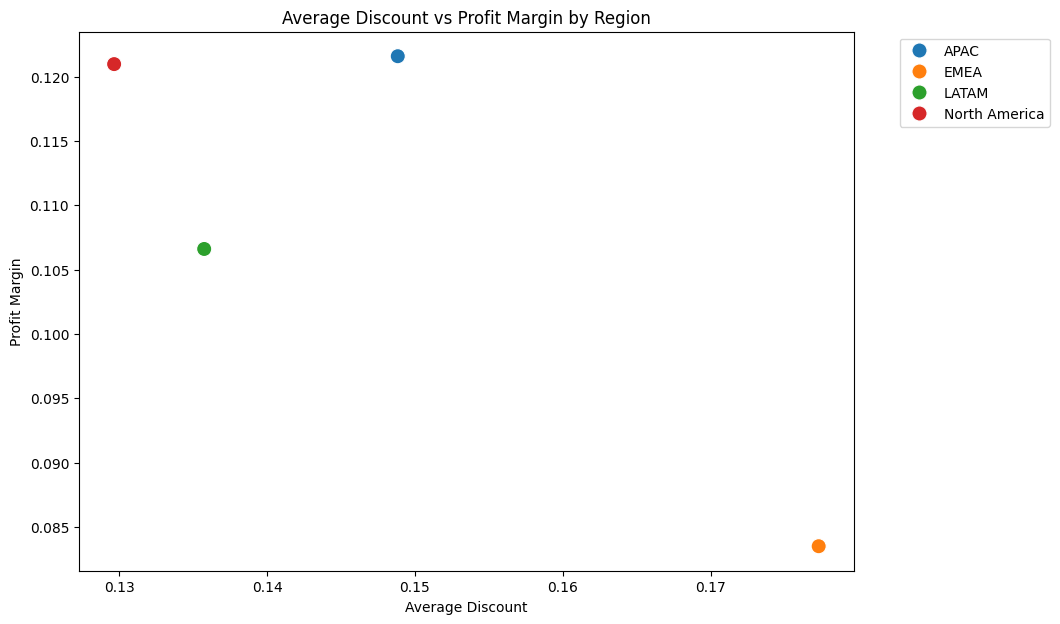

In [82]:
# Visualize the relationship between average discount and profit margin by region
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=region_summary,
    x="Discount",
    y="Profit_Margin",
    hue="Region",
    palette="tab10",
    s=120
)

plt.title("Average Discount vs Profit Margin by Region")
plt.xlabel("Average Discount")
plt.ylabel("Profit Margin")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

**Linear Regression**

In [83]:
# Import necessary libraries for regression analysis
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

In [84]:
# Prepare the data for regression analysis
X = df[["Discount"]]     # predictor 
y = df["Profit_Margin"]  # target

In [85]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [86]:
# Fit a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [87]:
# Display the coefficients of the regression model
model.coef_

array([-1.85844486])

In [88]:
# Display the intercept of the regression model
model.intercept_

np.float64(0.31328252239164767)

In [89]:
# Make predictions on the test set
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

r2, mse

(0.7174372824869168, 0.062278039235352)

R^2: 71.7% of the variation in profit margin is explained by disocunt alone. Which is very high for a single-variable business model. 

MSE: 0.062 error is relatively small compared to the spread of -4.7 to +0.58


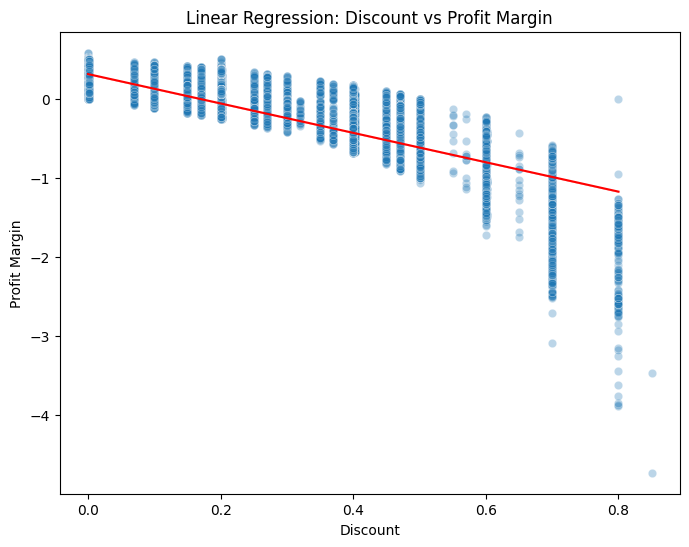

In [90]:
# Visualize the relationship between discount and profit margin with the regression line
plt.figure(figsize=(8,6))

sns.scatterplot(x=df["Discount"], y=df["Profit_Margin"], alpha=0.3)

sns.lineplot(
    x=X_test["Discount"],
    y=y_pred,
    color="red"
)

plt.title("Linear Regression: Discount vs Profit Margin")
plt.xlabel("Discount")
plt.ylabel("Profit Margin")
plt.show()